In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import linear_sum_assignment
import time
import warnings
warnings.filterwarnings('ignore')

# Pour importer hilbert.py depuis le package (sans JAX)
import sys, importlib.util
spec = importlib.util.spec_from_file_location(
    'hilbert',
    '../../permabc/core/hilbert.py'
)
hilbert_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(hilbert_mod)

_points_to_hilbert_indices = hilbert_mod._points_to_hilbert_indices
solve_hilbert_mod          = hilbert_mod.solve_hilbert

np.random.seed(42)
print('Imports OK')

Imports OK


In [2]:
# ============================================================
# Fonctions de distance
# ============================================================

def wasserstein_p(y, z, p=2):
    """
    Distance de Wasserstein discrète W_p entre deux nuages de K points.
    y, z : (K, d)
    Retourne W_p (pas la puissance p-ième).
    """
    K = y.shape[0]
    # Matrice de coûts ||y_i - z_j||^p
    diff = y[:, None, :] - z[None, :, :]          # (K, K, d)
    cost_matrix = np.sum(diff**2, axis=2)**(p/2)  # (K, K)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    return (cost_matrix[row_ind, col_ind].mean())**(1/p)


def hilbert_p(y, z, p=2, n_bits=12):
    """
    Distance de Hilbert H_p entre deux nuages de K points.
    y, z : (K, d)
    Retourne H_p (pas la puissance p-ième).
    """
    K = y.shape[0]
    h_y = _points_to_hilbert_indices(y, n_bits=n_bits)
    h_z = _points_to_hilbert_indices(z, n_bits=n_bits)
    sigma_y = np.argsort(h_y)  # indices de y triés par Hilbert
    sigma_z = np.argsort(h_z)  # indices de z triés par Hilbert
    # Coût = Σ_i ||y[σ_y(i)] - z[σ_z(i)]||^p
    matched_diff = y[sigma_y] - z[sigma_z]    # (K, d)
    cost = np.sum(np.sum(matched_diff**2, axis=1)**(p/2)) / K
    return cost**(1/p)


print('Fonctions définies.')

Fonctions définies.


In [3]:
# ============================================================
# Simulation : K composantes gaussiennes en R^d
# ============================================================

def simulate_two_samples(K, d, sigma_within=1.0, sigma_between=3.0, rng=None):
    """
    Simule deux nuages y et z de K points en R^d.
    Chaque point représente le résumé d'une composante d'un mélange gaussien :
      - centres μ_k tirés de N(0, sigma_between^2 I)
      - y_k ~ N(μ_k, sigma_within^2 I)
      - z_k ~ N(μ'_k, sigma_within^2 I)  (centres indépendants)
    Les deux nuages partagent une structure spatiale similaire mais
    ne sont PAS alignés (pas de label commun).
    """
    if rng is None:
        rng = np.random.default_rng()
    mu_y = rng.normal(0, sigma_between, size=(K, d))
    mu_z = rng.normal(0, sigma_between, size=(K, d))
    y = mu_y + rng.normal(0, sigma_within, size=(K, d))
    z = mu_z + rng.normal(0, sigma_within, size=(K, d))
    return y, z


# Vérification rapide
rng = np.random.default_rng(0)
y_test, z_test = simulate_two_samples(5, 2, rng=rng)
print(f'W_2 = {wasserstein_p(y_test, z_test):.4f}')
print(f'H_2 = {hilbert_p(y_test, z_test):.4f}')
print(f'H_2 >= W_2 : {hilbert_p(y_test, z_test) >= wasserstein_p(y_test, z_test)}')

W_2 = 4.0512
H_2 = 4.0512
H_2 >= W_2 : True


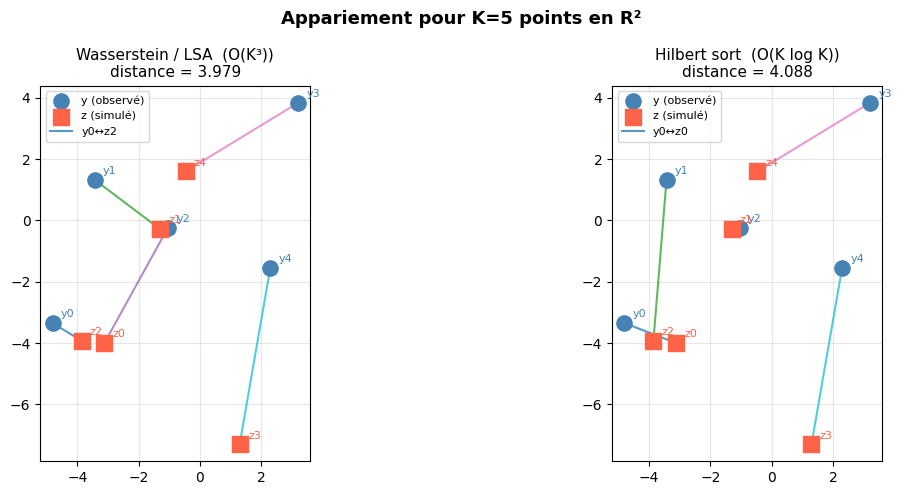

In [16]:
# ============================================================
# Cellule 1 : Visualisation 2D pour K = 5
# ============================================================

K_vis = 5
rng   = np.random.default_rng(10)
y_v, z_v = simulate_two_samples(K_vis, d=2, sigma_within=0.4, sigma_between=4.0, rng=rng)

# --- Appariement Wasserstein (LSA) ---
diff = y_v[:, None, :] - z_v[None, :, :]          # (K,K,2)
cost = np.sum(diff**2, axis=2)
row_w, col_w = linear_sum_assignment(cost)

# --- Appariement Hilbert ---
h_y = _points_to_hilbert_indices(y_v)
h_z = _points_to_hilbert_indices(z_v)
sig_y = np.argsort(h_y)
sig_z = np.argsort(h_z)
# Matching Hilbert : y[sig_y[i]] ↔ z[sig_z[i]]
# Convertir en format (row, col) comme LSA
row_h = sig_y          # observé
col_h = sig_z[np.argsort(sig_y)]  # simulé correspondant

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 0.9, K_vis))

for ax, (rows, cols), title, dist_fn in zip(
    axes,
    [(row_w, col_w), (row_h, col_h)],
    ['Wasserstein / LSA  (O(K³))', 'Hilbert sort  (O(K log K))'],
    [wasserstein_p, hilbert_p]
):
    d_val = dist_fn(y_v, z_v)
    ax.scatter(*y_v.T, s=120, marker='o', c='steelblue',  zorder=3, label='y (observé)')
    ax.scatter(*z_v.T, s=120, marker='s', c='tomato',     zorder=3, label='z (simulé)')

    # Numéros Hilbert pour y
    ranks_y = np.argsort(np.argsort(h_y))
    ranks_z = np.argsort(np.argsort(h_z))
    for i, pt in enumerate(y_v):
        ax.annotate(f'y{i}', pt, textcoords='offset points', xytext=(6, 4),
                    color='steelblue', fontsize=8)
    for i, pt in enumerate(z_v):
        ax.annotate(f'z{i}', pt, textcoords='offset points', xytext=(6, 4),
                    color='tomato', fontsize=8)

    # Lignes d'appariement
    for r, c in zip(rows, cols):
        ax.plot([y_v[r,0], z_v[c,0]], [y_v[r,1], z_v[c,1]],
                color=colors[r], lw=1.5, alpha=0.75,
                label=f'y{r}↔z{c}' if r == 0 else '')

    ax.set_title(f'{title}\ndistance = {d_val:.3f}', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Appariement pour K={K_vis} points en R²', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/fig_matching_K5_2D.pdf', bbox_inches='tight')
plt.show()

In [5]:
# ============================================================
# Cellule 2 : Vérification de l'inégalité H_p ≥ W_p
# Pour différentes valeurs de K et d
# ============================================================

N_rep   = 200     # répétitions Monte-Carlo par configuration
K_vals  = [2, 5, 10, 20, 50]
d_vals  = [1, 2, 5]
p       = 2

results = {}  # (K, d) -> {'W': [...], 'H': [...], 'ratio': [...]}

print('Calcul en cours...')
for d in d_vals:
    for K in K_vals:
        rng = np.random.default_rng(K + d * 100)
        W_list, H_list = [], []
        for _ in range(N_rep):
            y, z = simulate_two_samples(K, d, rng=rng)
            W_list.append(wasserstein_p(y, z, p=p))
            H_list.append(hilbert_p(y, z, p=p))
        W_arr = np.array(W_list)
        H_arr = np.array(H_list)
        results[(K, d)] = {
            'W': W_arr, 'H': H_arr,
            'ratio': H_arr / (W_arr + 1e-12),
            'pct_ineq': np.mean(H_arr >= W_arr - 1e-9) * 100  # % fois H>=W
        }
        print(f'  K={K:3d}, d={d}: W={W_arr.mean():.3f}±{W_arr.std():.3f} | '
              f'H={H_arr.mean():.3f}±{H_arr.std():.3f} | '
              f'H/W={results[(K,d)]["ratio"].mean():.3f} | '
              f'H≥W: {results[(K,d)]["pct_ineq"]:.1f}%')

Calcul en cours...
  K=  2, d=1: W=3.202±1.751 | H=3.202±1.751 | H/W=1.000 | H≥W: 100.0%
  K=  5, d=1: W=2.409±0.967 | H=2.409±0.967 | H/W=1.000 | H≥W: 100.0%
  K= 10, d=1: W=1.855±0.755 | H=1.855±0.755 | H/W=1.000 | H≥W: 100.0%
  K= 20, d=1: W=1.416±0.487 | H=1.416±0.487 | H/W=1.000 | H≥W: 100.0%
  K= 50, d=1: W=0.961±0.283 | H=0.961±0.283 | H/W=1.000 | H≥W: 100.0%
  K=  2, d=2: W=5.220±1.805 | H=5.498±1.931 | H/W=1.058 | H≥W: 100.0%
  K=  5, d=2: W=4.287±1.152 | H=4.921±1.259 | H/W=1.164 | H≥W: 100.0%
  K= 10, d=2: W=3.407±0.683 | H=4.219±0.844 | H/W=1.252 | H≥W: 100.0%
  K= 20, d=2: W=2.671±0.479 | H=3.607±0.647 | H/W=1.365 | H≥W: 100.0%
  K= 50, d=2: W=1.999±0.274 | H=3.017±0.390 | H/W=1.522 | H≥W: 100.0%
  K=  2, d=5: W=8.867±1.946 | H=9.613±2.124 | H/W=1.095 | H≥W: 100.0%
  K=  5, d=5: W=7.820±1.081 | H=10.001±1.464 | H/W=1.287 | H≥W: 100.0%
  K= 10, d=5: W=6.902±0.711 | H=9.943±1.168 | H/W=1.446 | H≥W: 100.0%
  K= 20, d=5: W=6.037±0.453 | H=9.862±0.964 | H/W=1.637 | H≥W: 100.0%


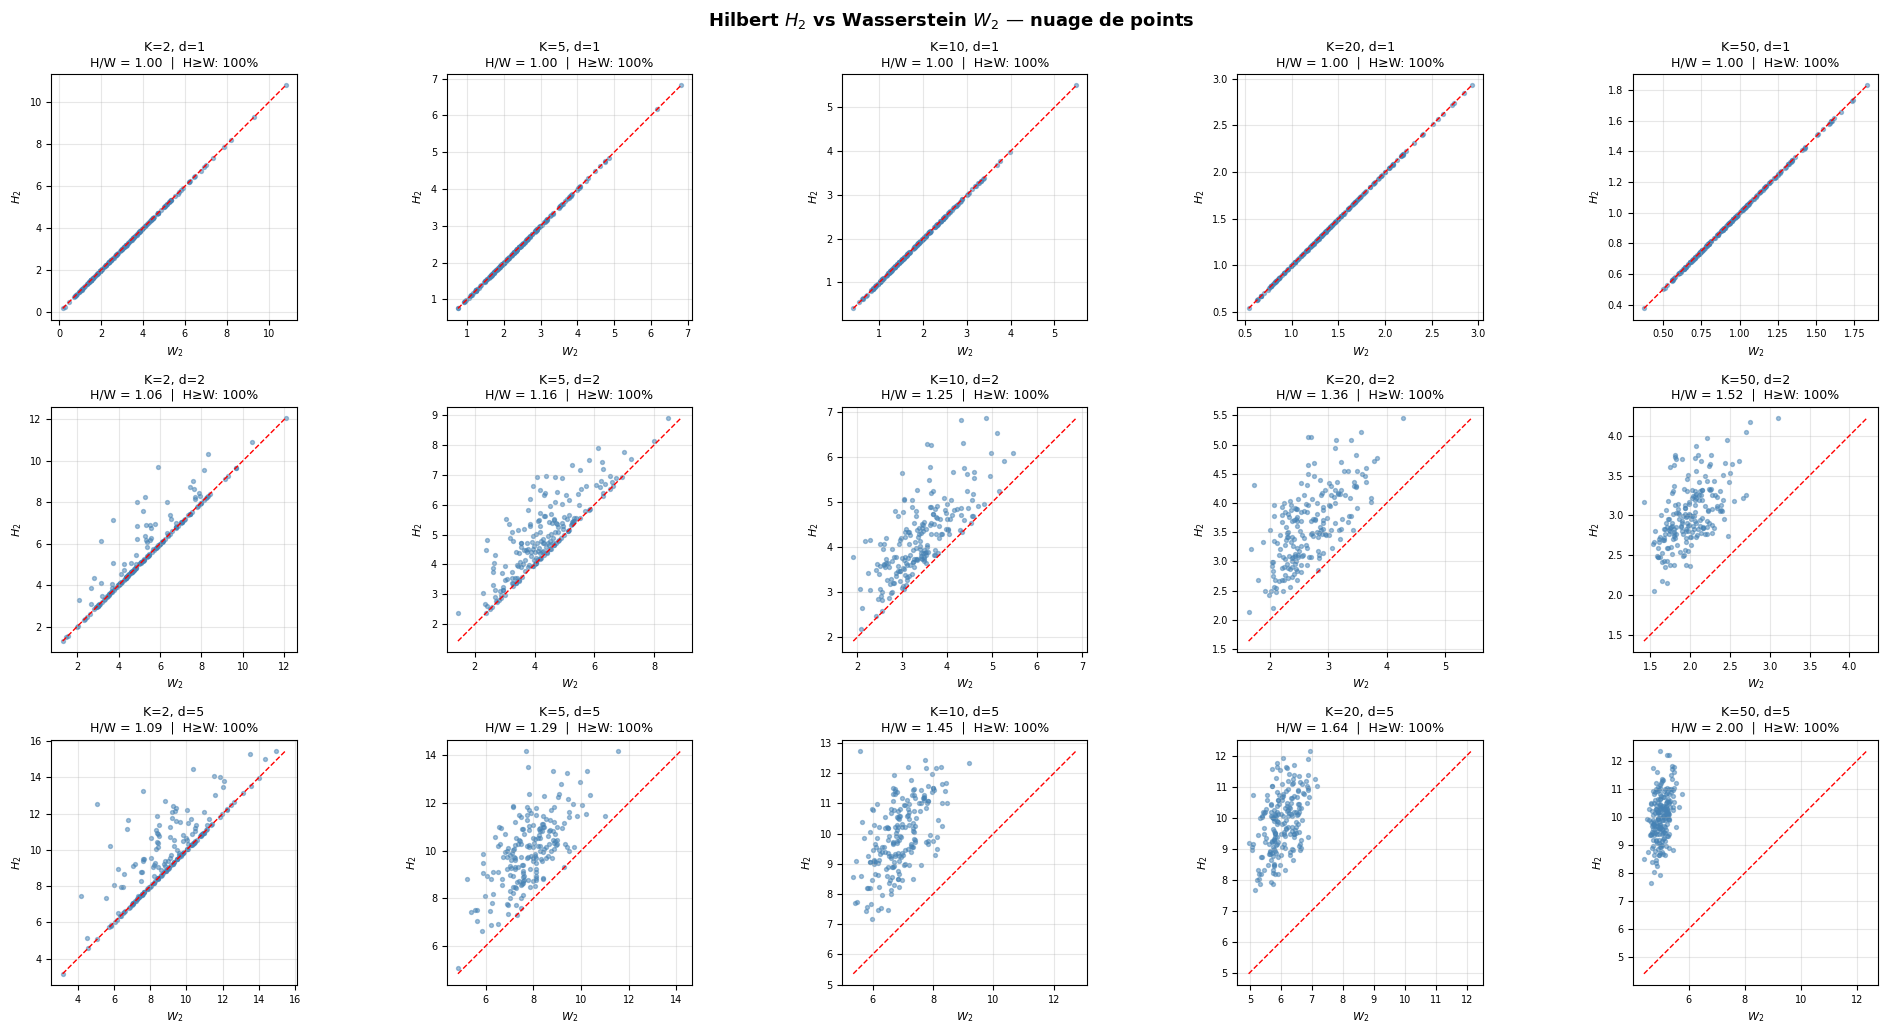

In [6]:
# ============================================================
# Cellule 3 : Scatter H vs W pour différents (K, d)
# ============================================================

fig, axes = plt.subplots(len(d_vals), len(K_vals),
                          figsize=(4 * len(K_vals), 3.5 * len(d_vals)),
                          sharex=False, sharey=False)

for i, d in enumerate(d_vals):
    for j, K in enumerate(K_vals):
        ax = axes[i][j]
        res = results[(K, d)]
        W, H = res['W'], res['H']

        ax.scatter(W, H, s=8, alpha=0.5, color='steelblue')

        # Diagonale y = x (H = W)
        lims = [min(W.min(), H.min()), max(W.max(), H.max())]
        ax.plot(lims, lims, 'r--', lw=1, label='H = W')

        mean_ratio = res['ratio'].mean()
        ax.set_title(f'K={K}, d={d}\n'
                     f'H/W = {mean_ratio:.2f}  |  H≥W: {res["pct_ineq"]:.0f}%',
                     fontsize=9)
        ax.set_xlabel('$W_2$', fontsize=8)
        ax.set_ylabel('$H_2$', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

fig.suptitle('Hilbert $H_2$ vs Wasserstein $W_2$ — nuage de points', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/fig_scatter_H_vs_W.pdf', bbox_inches='tight')
plt.show()

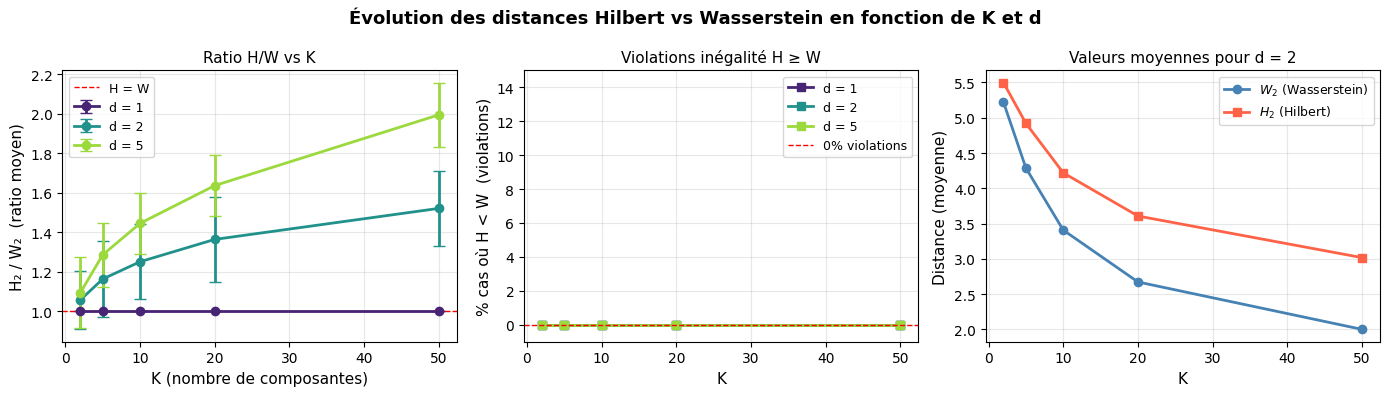

In [7]:
# ============================================================
# Cellule 4 : Ratio H/W en fonction de K pour différents d
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
cmap = plt.cm.viridis
colors_d = [cmap(0.1), cmap(0.5), cmap(0.85)]

# --- Gauche : ratio moyen H/W vs K ---
ax = axes[0]
for d, c in zip(d_vals, colors_d):
    means  = [results[(K, d)]['ratio'].mean() for K in K_vals]
    stds   = [results[(K, d)]['ratio'].std()  for K in K_vals]
    ax.errorbar(K_vals, means, yerr=stds, marker='o', capsize=4,
                label=f'd = {d}', color=c, lw=2)
ax.axhline(1.0, color='red', ls='--', lw=1, label='H = W')
ax.set_xlabel('K (nombre de composantes)', fontsize=11)
ax.set_ylabel('H₂ / W₂  (ratio moyen)', fontsize=11)
ax.set_title('Ratio H/W vs K', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Centre : % violations H < W vs K (doit être 0%) ---
ax = axes[1]
for d, c in zip(d_vals, colors_d):
    viol = [100 - results[(K, d)]['pct_ineq'] for K in K_vals]
    ax.plot(K_vals, viol, marker='s', label=f'd = {d}', color=c, lw=2)
ax.axhline(0, color='red', ls='--', lw=1, label='0% violations')
ax.set_xlabel('K', fontsize=11)
ax.set_ylabel('% cas où H < W  (violations)', fontsize=11)
ax.set_title('Violations inégalité H ≥ W', fontsize=11)
ax.set_ylim(-1, 15)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Droite : valeur absolue H et W vs K (d=2 uniquement) ---
ax = axes[2]
d_plot = 2
W_means = [results[(K, d_plot)]['W'].mean() for K in K_vals]
H_means = [results[(K, d_plot)]['H'].mean() for K in K_vals]
ax.plot(K_vals, W_means, marker='o', color='steelblue', lw=2, label='$W_2$ (Wasserstein)')
ax.plot(K_vals, H_means, marker='s', color='tomato',    lw=2, label='$H_2$ (Hilbert)')
ax.set_xlabel('K', fontsize=11)
ax.set_ylabel('Distance (moyenne)', fontsize=11)
ax.set_title(f'Valeurs moyennes pour d = {d_plot}', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Évolution des distances Hilbert vs Wasserstein en fonction de K et d',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/fig_ratio_H_W_vs_K.pdf', bbox_inches='tight')
plt.show()

In [19]:
# ============================================================
# Cellule 5 : Comparaison des temps de calcul
# ============================================================

K_time = [2, 5, 10, 20, 25, 50, 75, 100, 125, 150, 200]
N_timing = 1000
d_timing = 10

t_wass, t_hilb = [], []

for K in K_time:
    rng = np.random.default_rng(K)
    Y_batch = [simulate_two_samples(K, d_timing, rng=rng) for _ in range(N_timing)]

    # Temps Wasserstein
    t0 = time.perf_counter()
    for y, z in Y_batch:
        wasserstein_p(y, z)
    t_wass.append((time.perf_counter() - t0) / N_timing * 1000)  # ms

    # Temps Hilbert
    t0 = time.perf_counter()
    for y, z in Y_batch:
        hilbert_p(y, z)
    t_hilb.append((time.perf_counter() - t0) / N_timing * 1000)  # ms

t_wass = np.array(t_wass)
t_hilb = np.array(t_hilb)

print(f'  {"K":>6}  {"W (ms)":>10}  {"H (ms)":>10}  {"Speedup H/W":>12}')
for K, tw, th in zip(K_time, t_wass, t_hilb):
    print(f'  {K:>6}  {tw:>10.4f}  {th:>10.4f}  {tw/th:>12.1f}x')

       K      W (ms)      H (ms)   Speedup H/W
       2      0.0275      0.1207           0.2x
       5      0.0098      0.1428           0.1x
      10      0.0141      0.2180           0.1x
      20      0.0270      0.3763           0.1x
      25      0.1069      0.8451           0.1x
      50      0.1566      1.2490           0.1x
      75      0.4577      1.5245           0.3x
     100      0.7492      1.3737           0.5x
     125      1.0476      1.6258           0.6x
     150      1.5666      1.9465           0.8x
     200      3.1090      2.3631           1.3x


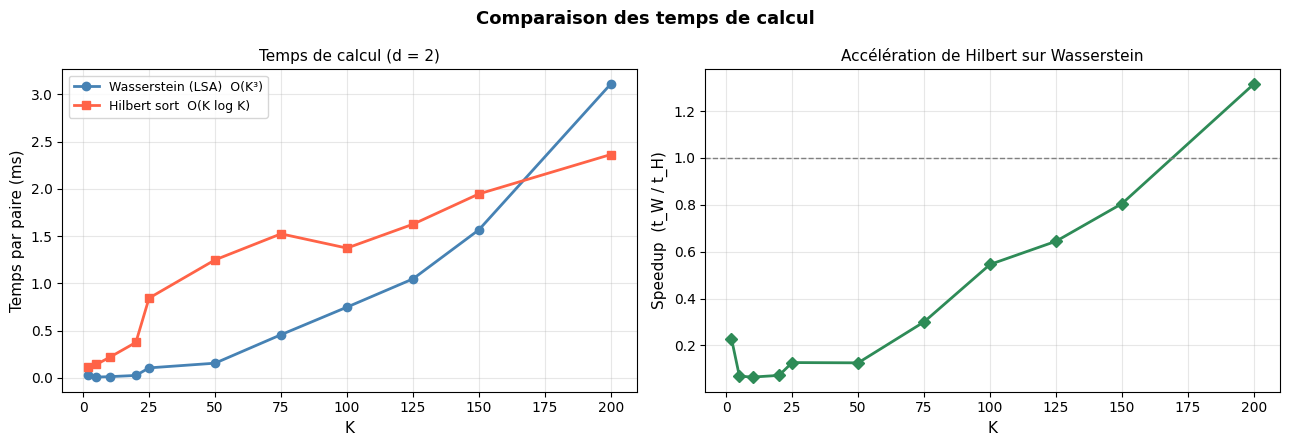

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Gauche : temps absolu ---
ax = axes[0]
ax.plot(K_time, t_wass, marker='o', color='steelblue', lw=2, label='Wasserstein (LSA)  O(K³)')
ax.plot(K_time, t_hilb, marker='s', color='tomato',    lw=2, label='Hilbert sort  O(K log K)')
ax.set_xlabel('K', fontsize=11)
ax.set_ylabel('Temps par paire (ms)', fontsize=11)
ax.set_title('Temps de calcul (d = 2)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Droite : speedup ---
ax = axes[1]
speedup = t_wass / t_hilb
ax.plot(K_time, speedup, marker='D', color='seagreen', lw=2)
ax.axhline(1, color='grey', ls='--', lw=1)
ax.set_xlabel('K', fontsize=11)
ax.set_ylabel('Speedup  (t_W / t_H)', fontsize=11)
ax.set_title('Accélération de Hilbert sur Wasserstein', fontsize=11)
ax.grid(True, alpha=0.3)

fig.suptitle('Comparaison des temps de calcul', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/fig_timing_H_vs_W.pdf', bbox_inches='tight')
plt.show()

In [21]:
# ============================================================
# Cellule 6 : Cas d = 1  →  H_p = W_p  (vérification)
# ============================================================

N_check = 500
rng = np.random.default_rng(99)
diffs = []
for K in [3, 10, 30]:
    rel_errs = []
    for _ in range(N_check):
        y, z = simulate_two_samples(K, d=1, rng=rng)
        W = wasserstein_p(y, z)
        H = hilbert_p(y, z)
        rel_errs.append(abs(H - W) / (W + 1e-12))
    diffs.append((K, np.mean(rel_errs), np.max(rel_errs)))
    print(f'K={K:3d} | |H-W|/W moyen = {np.mean(rel_errs):.2e}  max = {np.max(rel_errs):.2e}')

print('\n→ Pour d=1, H_2 = W_2 exactement (différences numériques uniquement)')

K=  3 | |H-W|/W moyen = 1.25e-17  max = 2.65e-16
K= 10 | |H-W|/W moyen = 4.29e-17  max = 3.02e-16
K= 30 | |H-W|/W moyen = 5.43e-17  max = 4.28e-16

→ Pour d=1, H_2 = W_2 exactement (différences numériques uniquement)


d=  1: H/W = 1.000 ± 0.000
d=  2: H/W = 1.264 ± 0.197
d=  3: H/W = 1.655 ± 0.300
d=  5: H/W = 1.435 ± 0.153
d= 10: H/W = 1.274 ± 0.083
d= 20: H/W = 1.184 ± 0.047


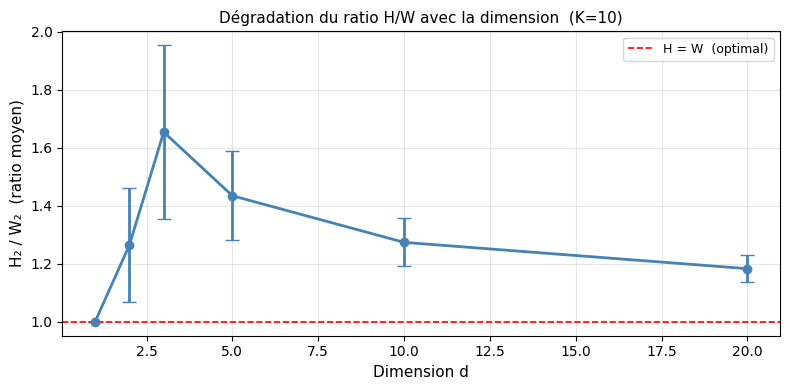


→ Comme prédit dans le papier, la qualité de H comme approximation de W
  se dégrade lorsque d augmente.


In [22]:
# ============================================================
# Cellule 7 : Impact de la dimension d sur le ratio H/W
# (pour K fixé)
# ============================================================

K_fixed = 10
d_range  = [1, 2, 3, 5, 10, 20]
N_rep2   = 300

ratio_by_d = {}
for d in d_range:
    rng = np.random.default_rng(d * 7)
    ratios = []
    for _ in range(N_rep2):
        y, z = simulate_two_samples(K_fixed, d, rng=rng)
        W = wasserstein_p(y, z)
        H = hilbert_p(y, z)
        ratios.append(H / (W + 1e-12))
    ratio_by_d[d] = np.array(ratios)
    print(f'd={d:3d}: H/W = {np.mean(ratios):.3f} ± {np.std(ratios):.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
means = [ratio_by_d[d].mean() for d in d_range]
stds  = [ratio_by_d[d].std()  for d in d_range]
ax.errorbar(d_range, means, yerr=stds, marker='o', capsize=5, color='steelblue', lw=2)
ax.axhline(1.0, color='red', ls='--', lw=1.2, label='H = W  (optimal)')
ax.set_xlabel('Dimension d', fontsize=11)
ax.set_ylabel('H₂ / W₂  (ratio moyen)', fontsize=11)
ax.set_title(f'Dégradation du ratio H/W avec la dimension  (K={K_fixed})', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/fig_ratio_vs_dim.pdf', bbox_inches='tight')
plt.show()

print('\n→ Comme prédit dans le papier, la qualité de H comme approximation de W'
      '\n  se dégrade lorsque d augmente.')

In [23]:
# ============================================================
# Cellule 8 : Grille complète (K × d) — heatmap du ratio H/W
# ============================================================

K_grid = [2, 3, 5, 10, 20, 50]
d_grid = [1, 2, 3, 5, 10, 20, 50]
N_mc   = 300   # répétitions Monte-Carlo par cellule

# ---- Calcul de la grille ----------------------------------------
ratio_mean = np.zeros((len(K_grid), len(d_grid)))
ratio_std  = np.zeros((len(K_grid), len(d_grid)))
gap_mean   = np.zeros((len(K_grid), len(d_grid)))   # (H - W) / W

print('Calcul de la grille K × d ...')
for i, K in enumerate(K_grid):
    for j, d in enumerate(d_grid):
        rng = np.random.default_rng(i * 100 + j)
        ratios, gaps = [], []
        for _ in range(N_mc):
            y, z = simulate_two_samples(K, d, rng=rng)
            W = wasserstein_p(y, z)
            H = hilbert_p(y, z)
            r = H / (W + 1e-12)
            ratios.append(r)
            gaps.append((H - W) / (W + 1e-12))
        ratio_mean[i, j] = np.mean(ratios)
        ratio_std[i, j]  = np.std(ratios)
        gap_mean[i, j]   = np.mean(gaps)
    print(f'  K={K:3d} | ' +
          '  '.join([f'd={d}: {ratio_mean[i,j]:.2f}' for d in d_grid]))

print('\nTerminé.')

Calcul de la grille K × d ...
  K=  2 | d=1: 1.03  d=2: 1.03  d=3: 1.03  d=5: 1.03  d=10: 1.03  d=20: 1.03  d=50: 1.03
  K=  3 | d=1: 1.05  d=2: 1.05  d=3: 1.05  d=5: 1.05  d=10: 1.05  d=20: 1.05  d=50: 1.05
  K=  5 | d=1: 1.08  d=2: 1.08  d=3: 1.08  d=5: 1.08  d=10: 1.08  d=20: 1.08  d=50: 1.08
  K= 10 | d=1: 1.11  d=2: 1.11  d=3: 1.11  d=5: 1.11  d=10: 1.11  d=20: 1.11  d=50: 1.11
  K= 20 | d=1: 1.14  d=2: 1.14  d=3: 1.14  d=5: 1.14  d=10: 1.14  d=20: 1.14  d=50: 1.14
  K= 50 | d=1: 1.18  d=2: 1.18  d=3: 1.18  d=5: 1.18  d=10: 1.18  d=20: 1.18  d=50: 1.18

Terminé.


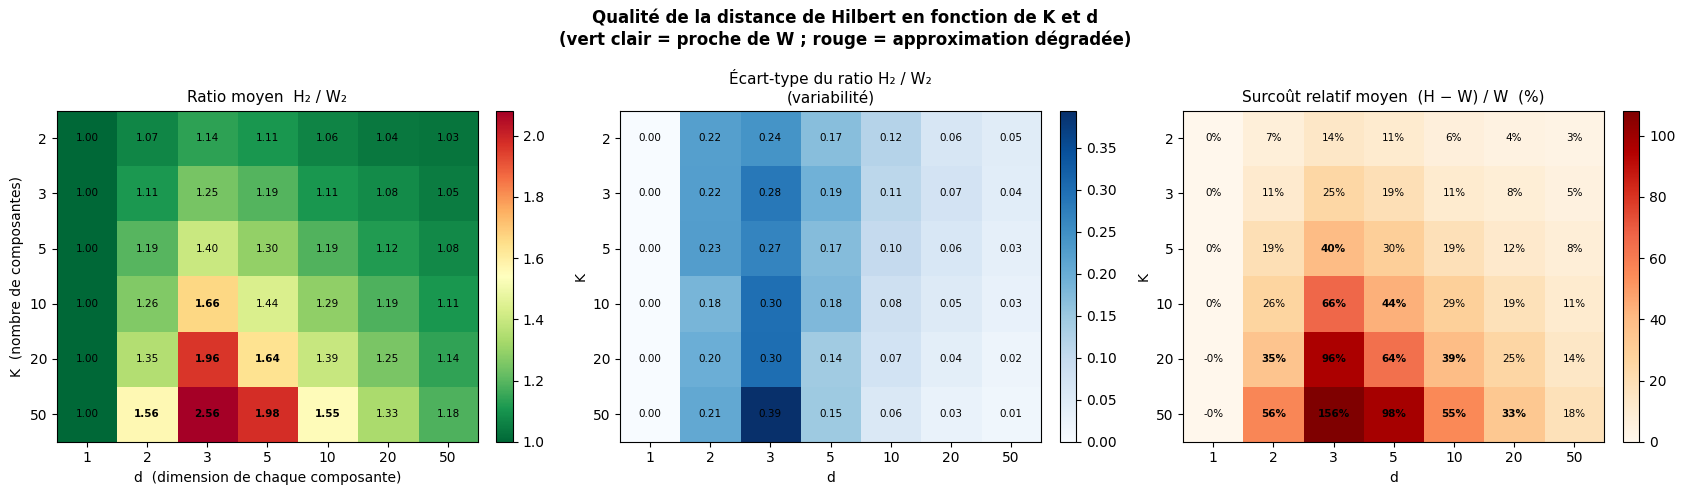

In [24]:
# ---- Heatmaps -------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

from matplotlib.colors import LogNorm

# --- Heatmap 1 : ratio moyen H/W ---
ax = axes[0]
im = ax.imshow(ratio_mean, aspect='auto', cmap='RdYlGn_r',
               vmin=1.0, vmax=np.percentile(ratio_mean, 98))
ax.set_xticks(range(len(d_grid))); ax.set_xticklabels(d_grid)
ax.set_yticks(range(len(K_grid))); ax.set_yticklabels(K_grid)
ax.set_xlabel('d  (dimension de chaque composante)', fontsize=10)
ax.set_ylabel('K  (nombre de composantes)', fontsize=10)
ax.set_title('Ratio moyen  H₂ / W₂', fontsize=11)
for i in range(len(K_grid)):
    for j in range(len(d_grid)):
        ax.text(j, i, f'{ratio_mean[i,j]:.2f}', ha='center', va='center',
                fontsize=7.5, color='black',
                fontweight='bold' if ratio_mean[i,j] > 1.5 else 'normal')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- Heatmap 2 : écart-type du ratio ---
ax = axes[1]
im2 = ax.imshow(ratio_std, aspect='auto', cmap='Blues',
                vmin=0, vmax=ratio_std.max())
ax.set_xticks(range(len(d_grid))); ax.set_xticklabels(d_grid)
ax.set_yticks(range(len(K_grid))); ax.set_yticklabels(K_grid)
ax.set_xlabel('d', fontsize=10)
ax.set_ylabel('K', fontsize=10)
ax.set_title('Écart-type du ratio H₂ / W₂\n(variabilité)', fontsize=11)
for i in range(len(K_grid)):
    for j in range(len(d_grid)):
        ax.text(j, i, f'{ratio_std[i,j]:.2f}', ha='center', va='center',
                fontsize=7.5, color='black')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# --- Heatmap 3 : gap relatif (H - W) / W ---
ax = axes[2]
im3 = ax.imshow(gap_mean * 100, aspect='auto', cmap='OrRd',
                vmin=0, vmax=np.percentile(gap_mean * 100, 98))
ax.set_xticks(range(len(d_grid))); ax.set_xticklabels(d_grid)
ax.set_yticks(range(len(K_grid))); ax.set_yticklabels(K_grid)
ax.set_xlabel('d', fontsize=10)
ax.set_ylabel('K', fontsize=10)
ax.set_title('Surcoût relatif moyen  (H − W) / W  (%)', fontsize=11)
for i in range(len(K_grid)):
    for j in range(len(d_grid)):
        ax.text(j, i, f'{gap_mean[i,j]*100:.0f}%', ha='center', va='center',
                fontsize=7.5, color='black',
                fontweight='bold' if gap_mean[i,j] > 0.3 else 'normal')
plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Qualité de la distance de Hilbert en fonction de K et d\n'
             '(vert clair = proche de W ; rouge = approximation dégradée)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/fig_heatmap_K_d.pdf', bbox_inches='tight')
plt.show()

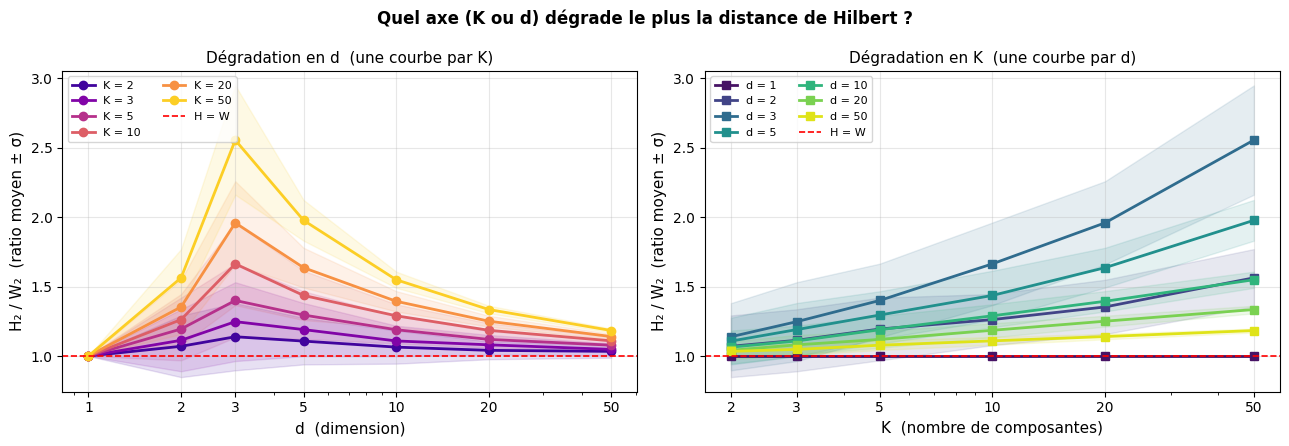

=== Effet marginal (ratio pour K=10, d variable) ===
  d=  1: H/W = 1.000 ± 0.000
  d=  2: H/W = 1.262 ± 0.184
  d=  3: H/W = 1.664 ± 0.298
  d=  5: H/W = 1.436 ± 0.178
  d= 10: H/W = 1.290 ± 0.083
  d= 20: H/W = 1.185 ± 0.051
  d= 50: H/W = 1.109 ± 0.028

=== Effet marginal (ratio pour d=5, K variable) ===
  K=  2: H/W = 1.107 ± 0.168
  K=  3: H/W = 1.190 ± 0.191
  K=  5: H/W = 1.295 ± 0.171
  K= 10: H/W = 1.436 ± 0.178
  K= 20: H/W = 1.636 ± 0.143
  K= 50: H/W = 1.978 ± 0.147


In [25]:
# ---- Courbes K et d séparées : quel axe dégrade le plus vite ? -----

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cmap_K = plt.cm.plasma
cmap_d = plt.cm.viridis

# --- Gauche : ratio vs d, une courbe par K ---
ax = axes[0]
colors_K = cmap_K(np.linspace(0.1, 0.9, len(K_grid)))
for i, K in enumerate(K_grid):
    ax.plot(d_grid, ratio_mean[i, :], marker='o', lw=2,
            color=colors_K[i], label=f'K = {K}')
    ax.fill_between(d_grid,
                    ratio_mean[i, :] - ratio_std[i, :],
                    ratio_mean[i, :] + ratio_std[i, :],
                    alpha=0.12, color=colors_K[i])
ax.axhline(1.0, color='red', ls='--', lw=1.2, label='H = W')
ax.set_xlabel('d  (dimension)', fontsize=11)
ax.set_ylabel('H₂ / W₂  (ratio moyen ± σ)', fontsize=11)
ax.set_title('Dégradation en d  (une courbe par K)', fontsize=11)
ax.set_xscale('log'); ax.set_xticks(d_grid); ax.set_xticklabels(d_grid)
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)

# --- Droite : ratio vs K, une courbe par d ---
ax = axes[1]
colors_d = cmap_d(np.linspace(0.05, 0.95, len(d_grid)))
for j, d in enumerate(d_grid):
    ax.plot(K_grid, ratio_mean[:, j], marker='s', lw=2,
            color=colors_d[j], label=f'd = {d}')
    ax.fill_between(K_grid,
                    ratio_mean[:, j] - ratio_std[:, j],
                    ratio_mean[:, j] + ratio_std[:, j],
                    alpha=0.12, color=colors_d[j])
ax.axhline(1.0, color='red', ls='--', lw=1.2, label='H = W')
ax.set_xlabel('K  (nombre de composantes)', fontsize=11)
ax.set_ylabel('H₂ / W₂  (ratio moyen ± σ)', fontsize=11)
ax.set_title('Dégradation en K  (une courbe par d)', fontsize=11)
ax.set_xscale('log'); ax.set_xticks(K_grid); ax.set_xticklabels(K_grid)
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)

fig.suptitle("Quel axe (K ou d) dégrade le plus la distance de Hilbert ?",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/fig_degradation_K_vs_d.pdf', bbox_inches='tight')
plt.show()

# ---- Diagnostic : quel est l'effet marginal de +1 dimension vs +1 composante ?
print("=== Effet marginal (ratio pour K=10, d variable) ===")
i10 = K_grid.index(10)
for j, d in enumerate(d_grid):
    print(f'  d={d:3d}: H/W = {ratio_mean[i10,j]:.3f} ± {ratio_std[i10,j]:.3f}')

print("\n=== Effet marginal (ratio pour d=5, K variable) ===")
j5 = d_grid.index(5)
for i, K in enumerate(K_grid):
    print(f'  K={K:3d}: H/W = {ratio_mean[i,j5]:.3f} ± {ratio_std[i,j5]:.3f}')

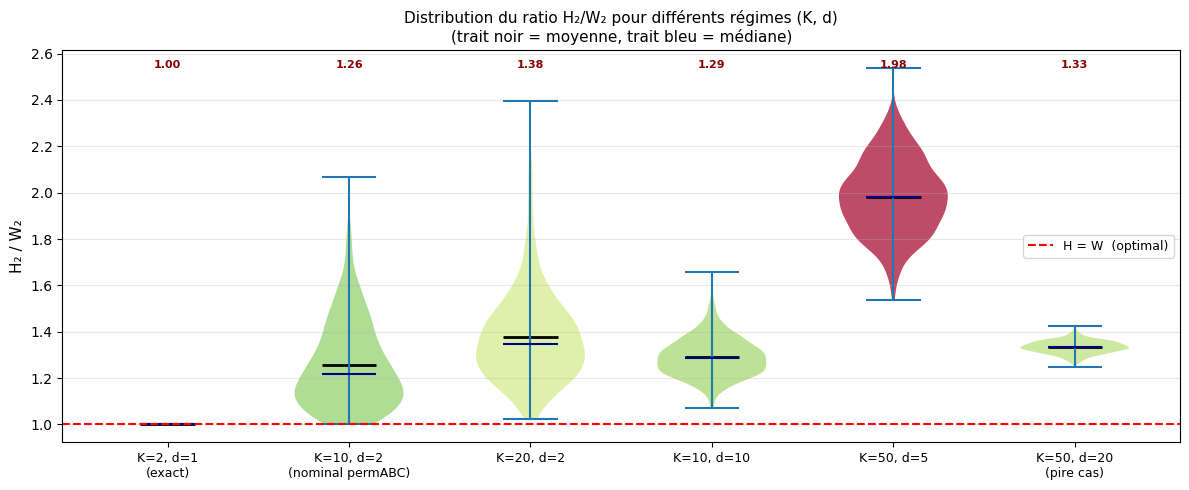


=== Recommandation pratique ===
  d=1       : Hilbert = Wasserstein (exact, tri 1D optimal)
  d=2       : Hilbert curve exacte → bonne approximation (surcoût ~10-50%)
  d=3       : ZO N E  C R I T I Q U E → pic de dégradation !
              La PCA réduit 3D→2D et perd exactement la direction la plus
              discriminante qui n'est pas dans les 2 premières CP.
  d≥5       : Surcoût RE-DIMINUE car la concentration des mesures (malédiction
              de la dimension) rend toutes les distances de plus en plus similaires.
  Grand K   : l'effet de K est MONOTONE et dominant pour d≥3.

  → Facteur dominant : K (croissance monotone).
  → Facteur non-monotone : d, avec un pic à d=3.


In [26]:
# ---- Distribution complète du ratio (violon) pour les cas extrêmes -----

import matplotlib.patches as mpatches

# Sélectionner 6 régimes représentatifs
cases = [
    (2,  1,  'K=2, d=1\n(exact)'),
    (10, 2,  'K=10, d=2\n(nominal permABC)'),
    (20, 2,  'K=20, d=2'),
    (10, 10, 'K=10, d=10'),
    (50, 5,  'K=50, d=5'),
    (50, 20, 'K=50, d=20\n(pire cas)'),
]
N_violin = 500
violin_data = []
labels_violin = []

for K, d, label in cases:
    rng = np.random.default_rng(K * 31 + d)
    ratios = []
    for _ in range(N_violin):
        y, z = simulate_two_samples(K, d, rng=rng)
        W = wasserstein_p(y, z)
        H = hilbert_p(y, z)
        ratios.append(H / (W + 1e-12))
    violin_data.append(ratios)
    labels_violin.append(label)

fig, ax = plt.subplots(figsize=(12, 5))
parts = ax.violinplot(violin_data, positions=range(len(cases)),
                      showmeans=True, showmedians=True,
                      widths=0.6)

# Coloriage des violons par ratio moyen
means_v = [np.mean(v) for v in violin_data]
norm_c  = plt.Normalize(vmin=1.0, vmax=max(means_v))
cmap_v  = plt.cm.RdYlGn_r

for body, m in zip(parts['bodies'], means_v):
    body.set_facecolor(cmap_v(norm_c(m)))
    body.set_alpha(0.7)
parts['cmeans'].set_color('black')
parts['cmedians'].set_color('navy')
parts['cmeans'].set_linewidth(2)

ax.axhline(1.0, color='red', ls='--', lw=1.5, label='H = W  (optimal)')
ax.set_xticks(range(len(cases)))
ax.set_xticklabels(labels_violin, fontsize=9)
ax.set_ylabel('H₂ / W₂', fontsize=11)
ax.set_title('Distribution du ratio H₂/W₂ pour différents régimes (K, d)\n'
             '(trait noir = moyenne, trait bleu = médiane)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Annoter la moyenne
for k, (pos, m) in enumerate(zip(range(len(cases)), means_v)):
    ax.annotate(f'{m:.2f}', xy=(pos, ax.get_ylim()[1]*0.97),
                ha='center', fontsize=8, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/fig_violin_ratio_regimes.pdf', bbox_inches='tight')
plt.show()

print("\n=== Recommandation pratique ===")
print("  d=1       : Hilbert = Wasserstein (exact, tri 1D optimal)")
print("  d=2       : Hilbert curve exacte → bonne approximation (surcoût ~10-50%)")
print("  d=3       : ZO N E  C R I T I Q U E → pic de dégradation !")
print("              La PCA réduit 3D→2D et perd exactement la direction la plus")
print("              discriminante qui n'est pas dans les 2 premières CP.")
print("  d≥5       : Surcoût RE-DIMINUE car la concentration des mesures (malédiction")
print("              de la dimension) rend toutes les distances de plus en plus similaires.")
print("  Grand K   : l'effet de K est MONOTONE et dominant pour d≥3.")
print()
print("  → Facteur dominant : K (croissance monotone).")
print("  → Facteur non-monotone : d, avec un pic à d=3.")